# Decide population and mutation models

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd                                                                                                                                                                                               

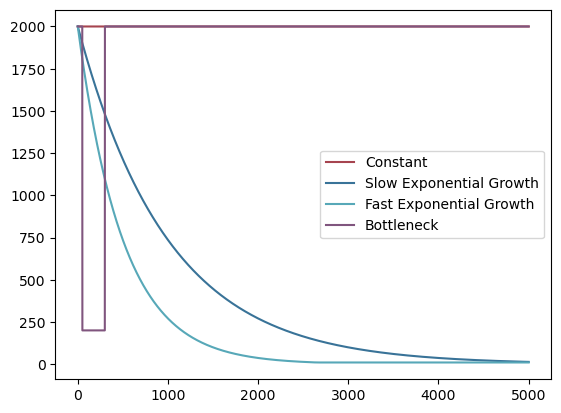

In [13]:
# current parameters for the trajectories

t_max = 5000
N_present = 2000

colors = ["#a6444f", "#397398", "#80557e", "#57a8b8"]  # Constant, Exp. growth, Exp. decline, Bottleneck

t_values = np.linspace(0, t_max, t_max * 10)
plt.plot(t_values, np.repeat(2000, len(t_values)), label= 'Constant', color = colors[0])
plt.plot(t_values, np.maximum(N_present * np.exp(-0.001 * t_values), 10), label= 'Slow Exponential Growth', color = colors[1])
plt.plot(t_values, np.maximum(N_present* np.exp(-0.002 * t_values), 10), label= 'Fast Exponential Growth', color = colors[3])
plt.plot(t_values, np.where((t_values < 50) | (t_values > 300), 2000, 200), color = colors[2], label= 'Bottleneck')
plt.legend()

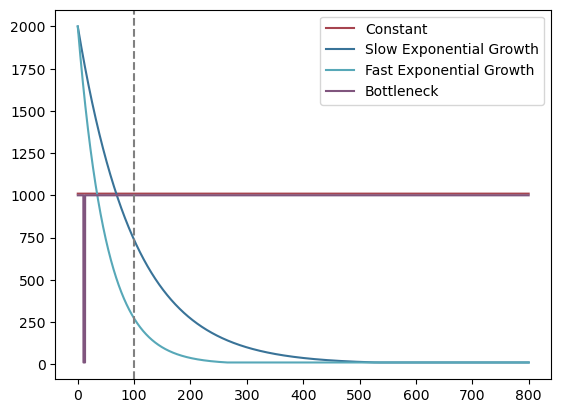

In [11]:
# current parameters for the trajectories

t_max = 800
N_present = 2000

colors = ["#a6444f", "#397398", "#80557e", "#57a8b8"]  # Constant, Exp. growth, Exp. decline, Bottleneck

t_values = np.linspace(0, t_max, t_max * 10)
plt.plot(t_values, np.repeat(1010, len(t_values)), label= 'Constant', color = colors[0])
plt.plot(t_values, np.maximum(N_present * np.exp(-0.01 * t_values), 10), label= 'Slow Exponential Growth', color = colors[1])
plt.plot(t_values, np.maximum(N_present* np.exp(-0.02 * t_values), 10), label= 'Fast Exponential Growth', color = colors[3])
# more realisitc would be 5 year bottleneck (pandemic)?
plt.plot(t_values, np.where((t_values < 10) | (t_values > 13), 1000, 10), color = colors[2], label= 'Bottleneck')
plt.axvline(x=100, color='grey', linestyle='--')
plt.legend()

# sampling span up to 1000 years?

## Expected number of mutations

In [ ]:
4.6e-8*10000000 # * combined branch length

0.46

                                         mean  median     std   min    max
sampling                popmodel                                          
independenthomochronous bottleneck     2751.0  2668.0   965.0  1161   6378
                        expgrowthfast  3087.0  3090.0   143.0  2722   3432
                        expgrowthslow  4053.0  4046.0   202.0  3564   4454
                        uniform        5450.0  5190.0  1211.0  3705  10201
linearconstant          bottleneck     5830.0  5542.0  1177.0  3684  10674
                        expgrowthfast  2966.0  2966.0   145.0  2643   3278
                        expgrowthslow  4193.0  4186.0   201.0  3626   4818
                        uniform        7236.0  6965.0  1263.0  5314  12260


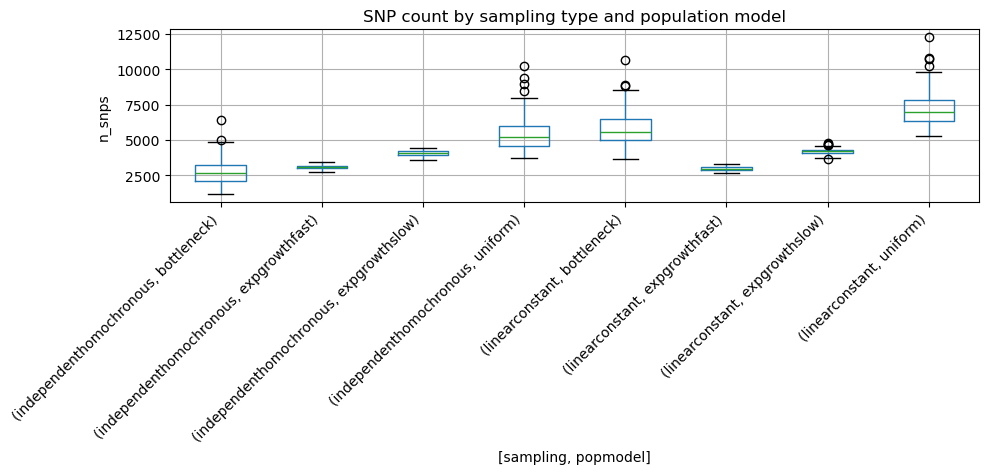

In [5]:
df = pd.read_csv("../results/run1/simulated_data/snp_summary.csv")                                                                                                                                                                        
                                                                                                                                                                                                                                         
summary = df.groupby(["sampling", "popmodel"])["n_snps"].agg(                                                                                                                                                                          
    mean="mean",                        
    median="median",                                                                                                                                                                                                                   
    std="std",                                                                                                                                                                                                                         
    min="min",
    max="max"                                                                                                                                                                                                                          
).round(0)      
                                            
print(summary)

fig, ax = plt.subplots(figsize=(10, 5))                                                                                                                                                                                                
df.boxplot(column="n_snps", by=["sampling", "popmodel"], ax=ax)
plt.xticks(rotation=45, ha="right")     
plt.suptitle("")
ax.set_title("SNP count by sampling type and population model")                                                                                                                                                                        
ax.set_ylabel("n_snps")                 
plt.tight_layout()                                                                                                                                                                                                                     
plt.show()  

In [2]:
import sys                                  
sys.path.insert(0, "../../population_size_impact")
from src.plotting.plot_prob_functions import plot_tMRCA_constN, plot_tMRCA_expN_present, plot_tMRCA_bottleneck
from src.metrics import calculate_coalescent_information_ratio_at_MAP, calculate_rel_mean_shift, calculate_rel_mean_shift_const, calculate_rel_mode_shift, calculate_rel_median_shift, calculate_rel_wasserstein_dist, calculate_rel_wasserstein2_dist, calculate_mode_shift, calculate_median_shift


Choice of k to get expected t_MRCA of around 200 years: 184


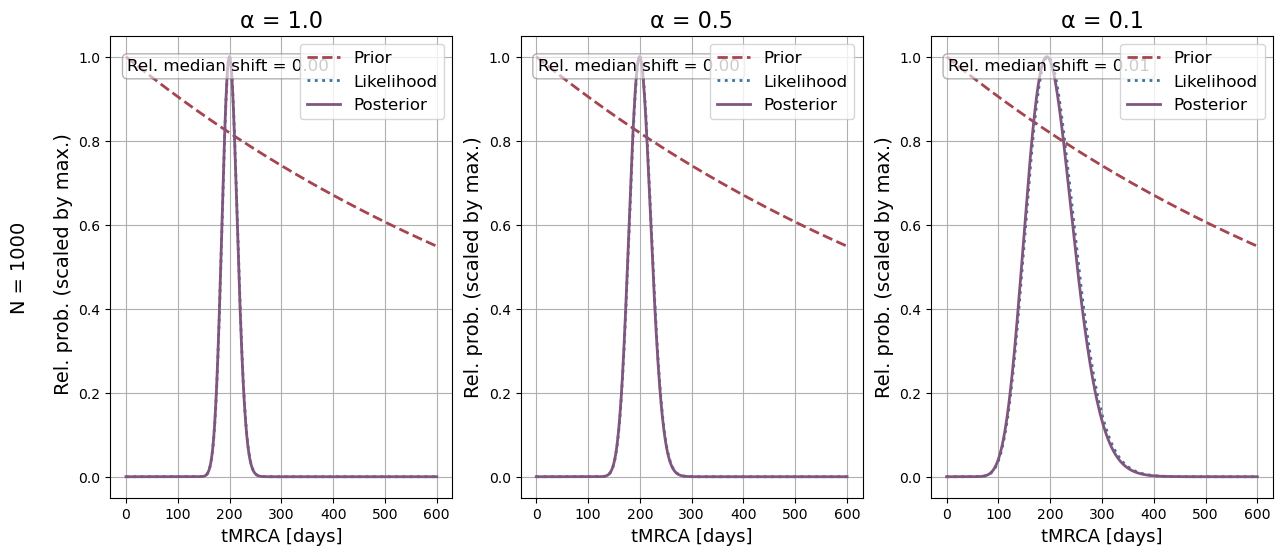

Population size 200 years ago (at expected tMRCA): [221.60631672  24.55467981]


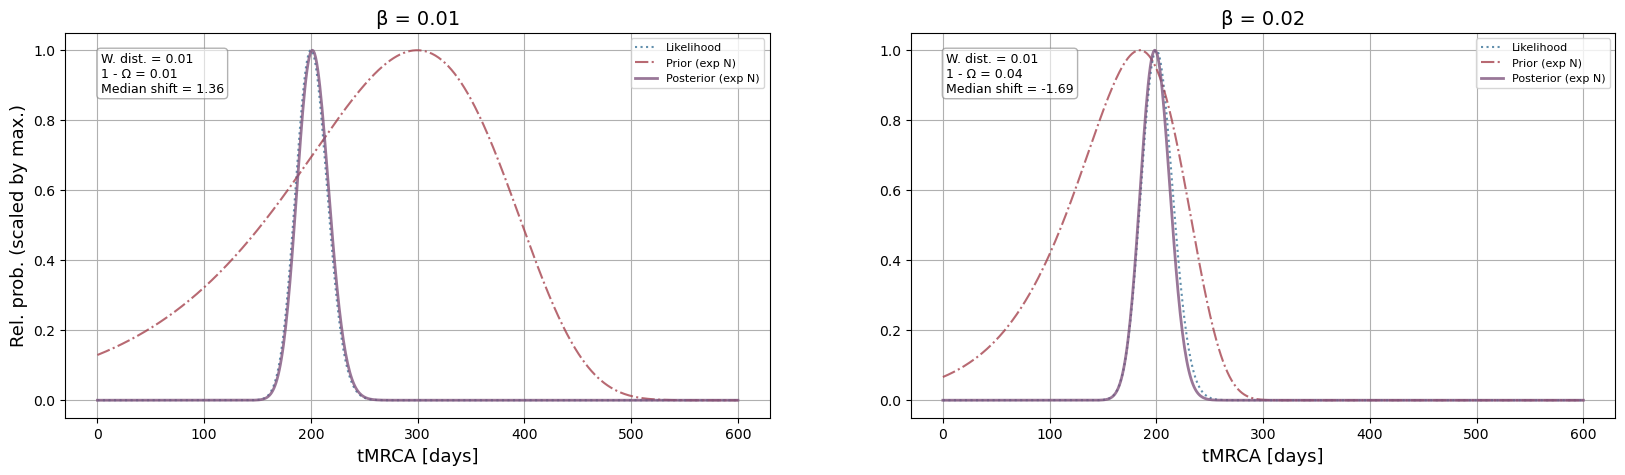

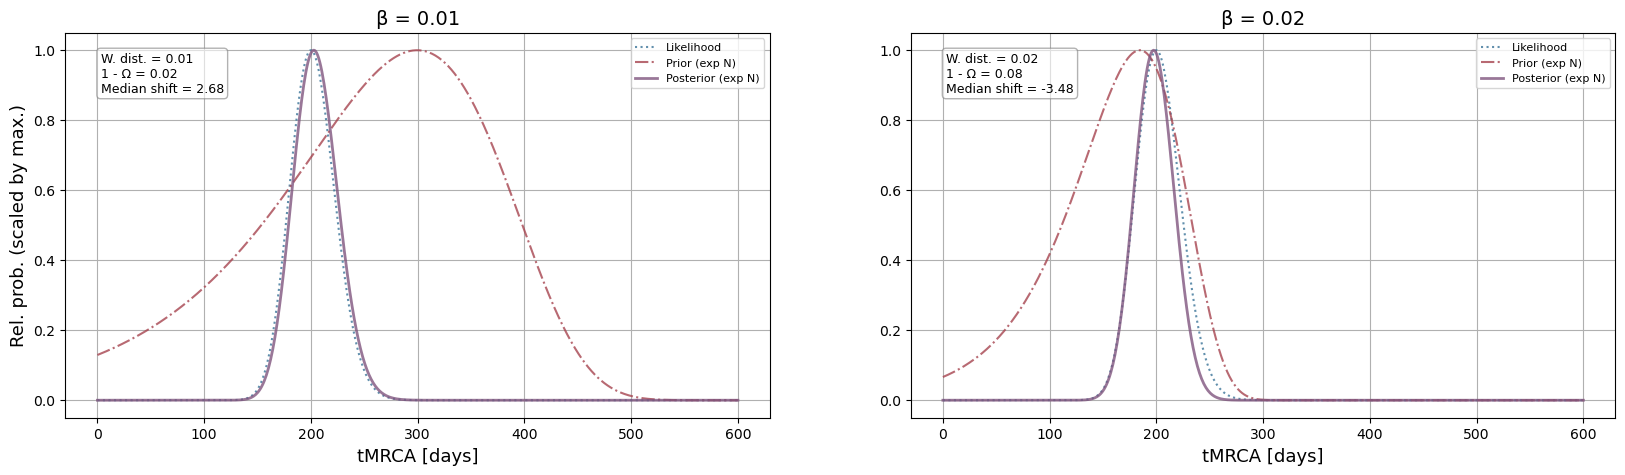

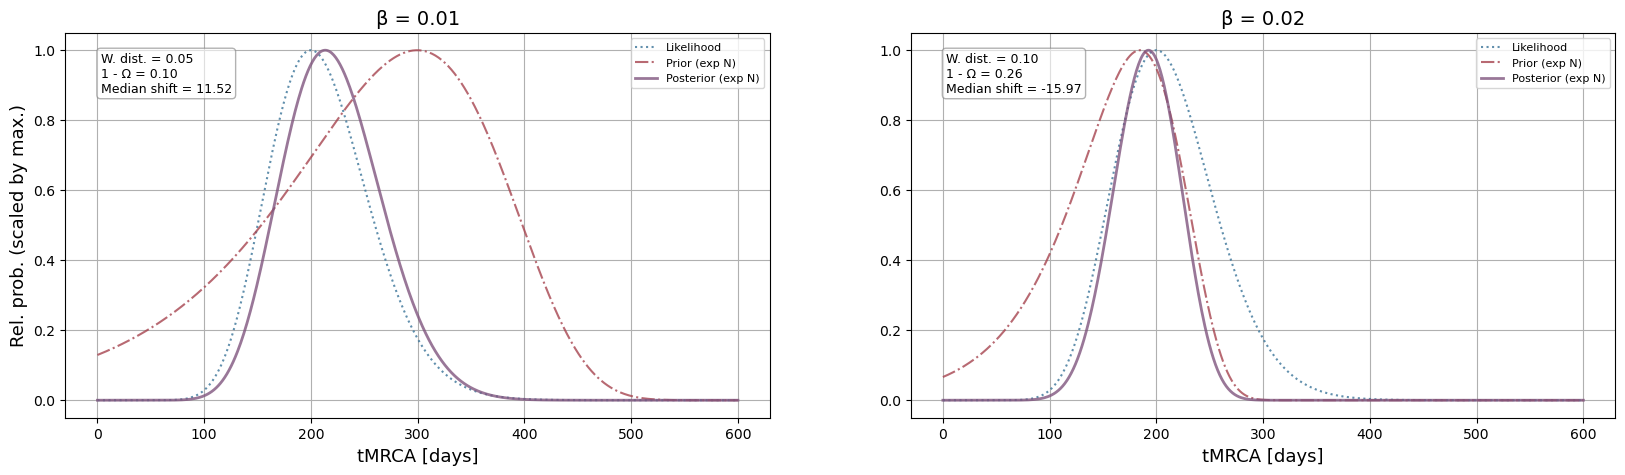

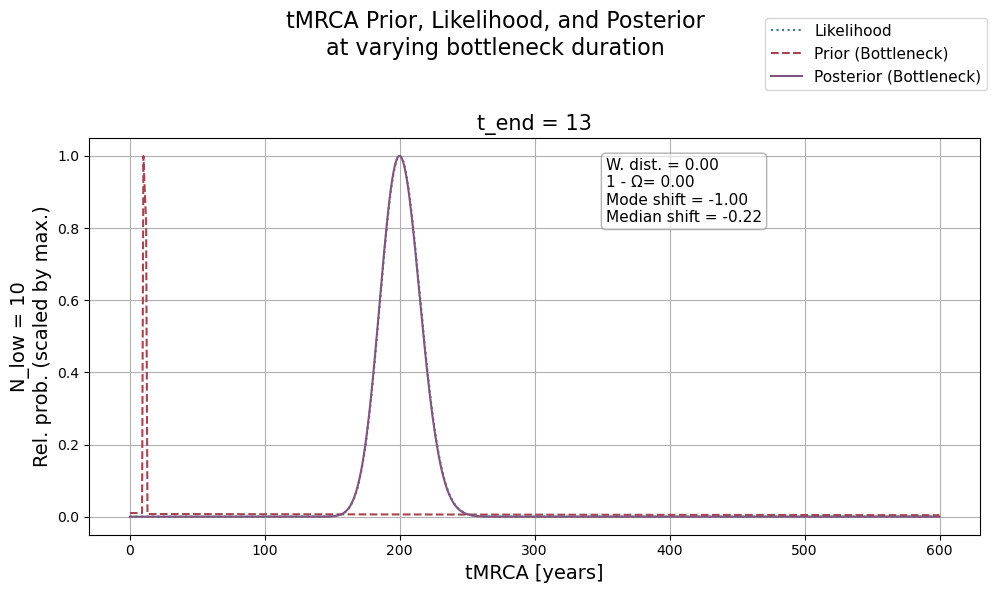

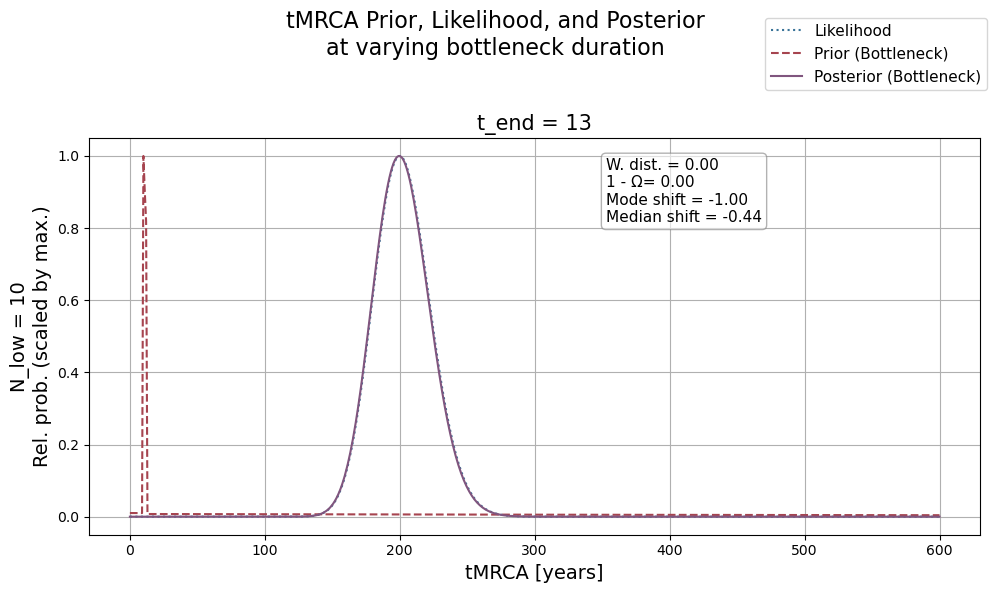

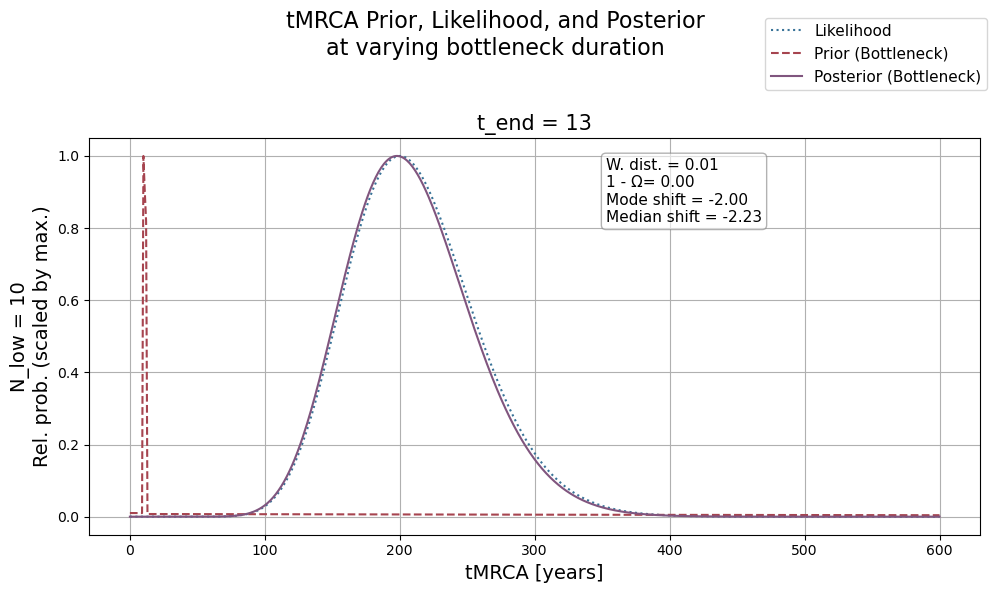

In [10]:
# Setup parameters
L = 10000000
N_values = [1000]  # Rows
alpha_values = [1.0, 0.5, 0.1]  # Columns
base_mu = 4.6e-8

print("Choice of k to get expected t_MRCA of around 200 years: " + str(int(200 * base_mu * L * 2))) 
base_k = 184 # such that tMRCA is around 200 years ago which could be realistic scenario with L = 10^7 and mu = 4.6e-8
t_max = 600  # Maximum tMRCA to consider

# be careful to increase time frame for metrics calculation:
# here analytic and numerical mean shift differ a lot because for the compuatation of the analytic mean shift not the whole likelihood distribution was considered (too small t_max)
metrics = [
    #(calculate_rel_wasserstein_dist, "Rel. W1", {}),
    #(calculate_rel_wasserstein2_dist, "W2", {}),
    (calculate_rel_median_shift, "Rel. median shift", {'abs_value': True}),
    #(calculate_rel_mode_shift, "Rel. mode shift", {'abs_value': True}),
    #(calculate_rel_mean_shift_const, "Rel. mean shift", {'abs_value': True}),
    #(calculate_rel_mean_shift, "Rel. mean shift numeric", {'abs_value': True}),
    #(calculate_mode_shift, "Mode shift", {'abs_value': True}),
    #(calculate_coalescent_information_ratio_at_MAP, "1 - Ω", {'reverse_scale': True}),
]


#plot_tMRCA_constN(N_values, alpha_values, base_mu, base_k, t_max, L, metrics=metrics, title = "Prior, Likelihood, and Posterior of tMRCA at varying population size N (rows) and varying variance of the likelihood α (columns)")
plot_tMRCA_constN(N_values, alpha_values, base_mu, base_k, t_max, L, metrics=metrics, title = "", figsize=(15, 6))

print(f"Population size 200 years ago (at expected tMRCA): {np.exp(-np.array([0.01, 0.02])*220)*2000}")
plot_tMRCA_expN_present(mu = base_mu, L= L, k_mut= base_k, N_present = 2000, beta_vec = [0.01, 0.02], max_tmrca = t_max, N = None, plot_comparison_to_const=False)
plot_tMRCA_expN_present(mu = base_mu, L= L*alpha_values[1], k_mut= base_k*alpha_values[1], N_present = 2000, beta_vec = [0.01, 0.02], max_tmrca = t_max, N = None, plot_comparison_to_const=False)
plot_tMRCA_expN_present(mu = base_mu, L= L*alpha_values[2], k_mut= base_k*alpha_values[2], N_present = 2000, beta_vec = [0.01, 0.02], max_tmrca = t_max, N = None, plot_comparison_to_const=False)

plot_tMRCA_bottleneck(base_mu, L, base_k, N_high = 1000, N_low_vec = [10], t_bottleneck_start = 10, t_bottleneck_end_vec = [13], t_max = t_max, time_scale='years', figsize=(10, 6))
plot_tMRCA_bottleneck(base_mu, L*alpha_values[1], base_k*alpha_values[1], N_high = 1000, N_low_vec = [10], t_bottleneck_start = 10, t_bottleneck_end_vec = [13], t_max = t_max, time_scale='years', figsize=(10, 6))
plot_tMRCA_bottleneck(base_mu, L*alpha_values[2], base_k*alpha_values[2], N_high = 1000, N_low_vec = [10], t_bottleneck_start = 10, t_bottleneck_end_vec = [13], t_max = t_max, time_scale='years', figsize=(10, 6))



In [ ]:
# check tree lengths

from Bio import Phylo                                                                                                                                                                                                                     
from io import StringIO                                                                                                                                                                                                                   
import pandas as pd                                                                                                                                                                                                                       
                                                                                                                                                                                                                                            
SIMDATA = "../results/run1/simulated_data"                                                                                                                                                                                                
SAMPLING_TYPES = ["independenthomochronous", "linearconstant"]
POP_MODELS = ["expgrowthfast", "expgrowthslow", "uniform", "bottleneck"]                                                                                                                                                                  
                                                                                                                                                                                                                                        
rows = []                                                                                                                                                                                                                                 
for sampling in SAMPLING_TYPES:                                                                                                                                                                                                           
    for popmodel in POP_MODELS:
        path = f"{SIMDATA}/{sampling}/{popmodel}/{popmodel}.trees"                                                                                                                                                                        
        with open(path) as f:
            for i, line in enumerate(f):                                                                                                                                                                                                  
                line = line.strip()
                if not line:                                                                                                                                                                                                              
                    continue
                tree = Phylo.read(StringIO(line), "newick")
                max_root_to_tip = max(                                                                                                                                                                                                    
                    tree.distance(tree.root, tip) for tip in tree.get_terminals()
                )                                                                                                                                                                                                                         
                rows.append({
                    "sampling": sampling,                                                                                                                                                                                                 
                    "popmodel": popmodel,
                    "replicate": i,                                                                                                                                                                                                       
                    "max_root_to_tip": max_root_to_tip,
                })                                                                                                                                                                                                                        
                
df_tree_lengths = pd.DataFrame(rows)                                                                                                                                                                                                      
df_tree_lengths.head()

# 20s

df_tree_lengths.groupby(["sampling", "popmodel"])["max_root_to_tip"].describe()

count         mean          std  \
sampling                popmodel                                         
independenthomochronous bottleneck     100.0  1518.572517   932.924819   
                        expgrowthfast  100.0   211.082701    23.354517   
                        expgrowthslow  100.0   360.304274    44.999484   
                        uniform        100.0  1791.402098  1063.131792   
linearconstant          bottleneck     100.0  2105.700048  1115.136934   
                        expgrowthfast  100.0   218.433829    24.266170   
                        expgrowthslow  100.0   351.849180    42.368534   
                        uniform        100.0  2186.392682  1233.866017   

                                              min          25%          50%  \
sampling                popmodel                                              
independenthomochronous bottleneck     236.546783   900.313213  1266.854031   
                        expgrowthfast  153.401624   195.837307   210.147106   
                        expgrowthslow  252.136885   332.748270   359.099786   
                        uniform        420.505285  1060.134724  1471.441765   
linearconstant          bottleneck     629.853958  1296.855159  1900.082353   
                        expgrowthfast  159.137393   199.363842   217.239025   
                        expgrowthslow  263.483878   319.980262   352.389357   
                        uniform        706.556497  1438.169484  1870.483792   

                                               75%          max  
sampling                popmodel                                 
independenthomochronous bottleneck     1987.364305  4543.355486  
                        expgrowthfast   228.586869   264.759137  
                        expgrowthslow   391.244261   465.230463  
                        uniform        2311.646498  6934.015514  
linearconstant          bottleneck     2564.766429  7818.844968  
                        expgrowthfast   237.450589   275.868019  
                        expgrowthslow   379.035952   472.608053  
                        uniform        2412.745023  7347.224583

In [3]:
df_tree_lengths[df_tree_lengths["replicate"]==0]

,sampling,popmodel,replicate,max_root_to_tip
0,independenthomochronous,expgrowthfast,0,185.505381
100,independenthomochronous,expgrowthslow,0,365.246967
200,independenthomochronous,uniform,0,732.030606
300,independenthomochronous,bottleneck,0,1550.887710
400,linearconstant,expgrowthfast,0,219.123806
500,linearconstant,expgrowthslow,0,325.225102
600,linearconstant,uniform,0,1864.984670
700,linearconstant,bottleneck,0,1480.600105


rsync -avz beckermar@euler.ethz.ch:/cluster/work/stadler/beckermar/BESP_paper-analyses/benchmarks/ ./benchmarks/

rsync -avz --include="*/" --include="*.T0.xml" --exclude="*" \
beckermar@euler.ethz.ch:/cluster/work/stadler/beckermar/BESP_paper-analyses/results/run1/beast_inference/ \
./results/run1/beast_inference

rsync -avz --include="*/" --include="*_0_snps.fasta" --exclude="*" \
beckermar@euler.ethz.ch:/cluster/work/stadler/beckermar/BESP_paper-analyses/results/run1/simulated_data/ \
./results/run1/simulated_data/

rsync -av --progress --include="*/" --include="*.log" --exclude="*" beckermar@euler.ethz.ch:/cluster/work/stadler/beckermar/BESP_paper-analyses/results/run1/beast_inference/ ./results/run1/beast_inference/          
                                                                            


<scaleOperator scaleFactor="0.95" scaleAll="true" ignoreBounds="true" weight="1">
    <parameter idref="treeModel.allInternalNodeHeights"/>
</scaleOperator>

<scaleOperator scaleFactor="0.95" scaleAll="true" ignoreBounds="true" weight="1">
    <parameter idref="treeModel.allInternalNodeHeights"/>
</scaleOperator>

In [45]:
import pandas as pd                                                                                                                                                                                                                       
import glob                                                                                                                                                                                                                             
import os

rows = []
for f in glob.glob("../benchmarks/run_beast/*.tsv"):
    name = os.path.basename(f).replace(".tsv", "")
    parts = name.split("_")
    # filename: {model}_{sampling}_{popmodel}_{mutsig}_T{i}_seed{seed}
    model    = parts[0]                                                                                                                                                                                                                   
    sampling = parts[1]
    popmodel = parts[2]                                                                                                                                                                                                                   
    mutsig   = parts[3]                                                                                                                                                                                                                 
    replicate = parts[4]
    seed     = parts[5]
    df = pd.read_csv(f, sep="\t")
    df["model"]     = model
    df["sampling"]  = sampling
    df["popmodel"]  = popmodel
    df["mutsig"]    = mutsig
    df["replicate"] = replicate
    df["seed"]      = seed
    rows.append(df)

runtime_summary = pd.concat(rows, ignore_index=True)
runtime_summary = runtime_summary[["model", "sampling", "popmodel", "mutsig", "replicate", "seed", "s", "h:m:s", "max_rss", "mean_load"]]
runtime_summary.to_csv("../benchmarks/run_beast_summary.csv", index=False)                                                                                                                                                                           

# runtime overview
runtime_summary.groupby(["model", "sampling", "popmodel", "mutsig"])["s"].describe() / 3600 # in hours   

count  \
model     sampling                popmodel      mutsig                 
constcoal independenthomochronous bottleneck    highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  expgrowthfast highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  expgrowthslow highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  uniform       highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
          linearconstant          bottleneck    highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  expgrowthfast highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  expgrowthslow highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  uniform       highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
skyline   independenthomochronous bottleneck    highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  expgrowthfast highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  expgrowthslow highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  uniform       highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
          linearconstant          bottleneck    highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  expgrowthfast highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  expgrowthslow highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   
                                  uniform       highmutsig  0.000833   
                                                lowmutsig   0.000833   
                                                medmutsig   0.000833   

                                                                mean  \
model     sampling                popmodel      mutsig                 
constcoal independenthomochronous bottleneck    highmutsig  0.439519   
                                                lowmutsig   0.175921   
                                                medmutsig   0.337499   
                                  expgrowthfast highmutsig  0.593144   
                              

In [46]:
# memory usage overview
runtime_summary.groupby(["model", "sampling", "popmodel", "mutsig"])["max_rss"].describe()

count        mean  \
model     sampling                popmodel      mutsig                          
constcoal independenthomochronous bottleneck    highmutsig    3.0  172.103333   
                                                lowmutsig     3.0  159.960000   
                                                medmutsig     3.0  161.930000   
                                  expgrowthfast highmutsig    3.0  186.100000   
                                                lowmutsig     3.0  164.630000   
                                                medmutsig     3.0  174.280000   
                                  expgrowthslow highmutsig    3.0  198.456667   
                                                lowmutsig     3.0  163.553333   
                                                medmutsig     3.0  184.363333   
                                  uniform       highmutsig    3.0  190.733333   
                                                lowmutsig     3.0  166.930000   
                                                medmutsig     3.0  178.050000   
          linearconstant          bottleneck    highmutsig    3.0  191.586667   
                                                lowmutsig     3.0  170.236667   
                                                medmutsig     3.0  183.806667   
                                  expgrowthfast highmutsig    3.0  185.316667   
                                                lowmutsig     3.0  160.206667   
                                                medmutsig     3.0  171.620000   
                                  expgrowthslow highmutsig    3.0  201.186667   
                                                lowmutsig     3.0  169.356667   
                                                medmutsig     3.0  188.096667   
                                  uniform       highmutsig    3.0  196.643333   
                                                lowmutsig     3.0  171.616667   
                                                medmutsig     3.0  183.346667   
skyline   independenthomochronous bottleneck    highmutsig    3.0  181.910000   
                                                lowmutsig     3.0  258.310000   
                                                medmutsig     3.0  176.723333   
                                  expgrowthfast highmutsig    3.0  198.203333   
                                                lowmutsig     3.0  173.000000   
                                                medmutsig     3.0  180.343333   
                                  expgrowthslow highmutsig    3.0  199.036667   
                                                lowmutsig     3.0  169.000000   
                                                medmutsig     3.0  186.683333   
                                  uniform       highmutsig    3.0  192.350000   
                                                lowmutsig     3.0  172.923333   
                                                medmutsig     3.0  172.956667   
          linearconstant          bottleneck    highmutsig    3.0  201.230000   
                                                lowmutsig     3.0  188.090000   
                                                medmutsig     3.0  174.813333   
                                  expgrowthfast highmutsig    3.0  192.536667   
                                                lowmutsig     3.0  180.583333   
                                                medmutsig     3.0  187.170000   
                                  expgrowthslow highmutsig    3.0  197.020000   
                                                lowmutsig     3.0  222.576667   
                                                medmutsig     3.0  184.073333   
                                  uniform       highmutsig    3.0  202.246667   
                                                lowmutsig     3.0  182.093333   
                                                medmutsig     3.0  185.243333   

         

In [57]:
runtime_summary.sort_values(['model', 'sampling', 'popmodel', 'mutsig', 'replicate', 'seed'])[72:108]

,model,sampling,popmodel,mutsig,replicate,seed,s,h:m:s,max_rss,mean_load
112,skyline,independenthomochronous,bottleneck,highmutsig,T0,seed44,20634.85,5:43:54,189.23,116.98
121,skyline,independenthomochronous,bottleneck,highmutsig,T0,seed45,20928.08,5:48:48,178.56,114.69
110,skyline,independenthomochronous,bottleneck,highmutsig,T0,seed46,24160.85,6:42:40,177.94,114.45
76,skyline,independenthomochronous,bottleneck,lowmutsig,T0,seed44,12766.02,3:32:46,258.43,99.51
69,skyline,independenthomochronous,bottleneck,lowmutsig,T0,seed45,13982.11,3:53:02,225.45,99.69
61,skyline,independenthomochronous,bottleneck,lowmutsig,T0,seed46,13587.19,3:46:27,291.05,99.94
1,skyline,independenthomochronous,bottleneck,medmutsig,T0,seed44,20198.38,5:36:38,185.46,104.18
6,skyline,independenthomochronous,bottleneck,medmutsig,T0,seed45,18270.06,5:04:30,181.26,101.70
16,skyline,independenthomochronous,bottleneck,medmutsig,T0,seed46,18342.87,5:05:42,163.45,100.49
3,skyline,independenthomochronous,expgrowthfast,highmutsig,T0,seed44,8357.96,2:19:17,206.89,121.89


### Tracer analysis where we need longer / less long MCMC runs
Results are before I removed one of the operators

- constcoal: all 10.000.000 steps, all 4h
    - independenthomochroneous, 4h limit, 10.000.000 (with scale operator)
        - bottleneck: good for all, worst for highmutsig, all run < 1h
        - expgrowthfast: max. 1h 30min, all very good, could probably run shorter but already only 10.000.000
        - expgrowthslow: max 1h 10 min, all very good
        - uniform: max 1h, all very good
    - linearconstant: 4h, 30.000.000 (without scale operator)
        - bottleneck:
            - highmutsig: around 30 min, failed for single runs, not for combined, run a bit longer --> 30.000.000, 4h limit
            - medmutsig: around 30 min, failed for single runs, not for combined, a bit longer --> 30.000.000 4h limit
            - lowmutsig: one didnt pass, together pass, around 30 min --> 30.000.000, 4h
        - expgrowthfast: around 30 min, high just failed, med and low fine, --> still all to 30.000.000, 4h
        - expgrowthslow: up to 40 min, all okay but still --> 30.000.000 to be sure, 4h
        - uniform: up to 45 min, highmutsig need a little longer, two other are fine --> stil 30.000.000, 4h
- skyline, all 16h to be save
    - independenthomochroneous
        - bottleneck:
            - highmutsig failed with 80.000.000 and up to 6h --> run longer: 160.000.000, time limit 16h
            - medmutsig failed with 80.000.000 and up to 3h 30 min --> run longer: 160.000.000, time limit 8h
            - lowmutsig failed with 120.000.000 and up to 3h --> run longer: 200.000.000, time limit 8h
        - expgrowthfast: 
            - highmutsig very successful and up to 10h --> run shorter, lets try 40.000.000, time limit 8h
            - medmutsig successful and up to 6h --> keep as it is, time limit 8h
            - lowmutsig just successful and up to 4h 30 min --> don't run shorter, maybe 140.000.000, time limit 8h
        - expgrowthslow:
            - highmutsig very successful and up to 7h 30 min --> run shorter, lets try 40.000.000, time limit 8h
            - medmutsig keep as it is and up to 6h 30 min --> keep, time limit 8h
            - lowmutsig failed and up to 5h --> run longer, lets try 200.000.000, time limit 16h
        - uniform:
            - highmutsig very successful and up to 6h 30 min --> run shorter, lets try 40.000.000, time limit 8h
            - medmutsig successfup and up to 6h --> keep as it is, time limit 8h
            - lowmutsig failed but nearly successful and up to 5h --> run longer but lets try 150.000.000, time limit 8h
    - linearconstant:
        - bottleneck:
            - highmutsig seems to fail: --> 160.000.000
            - medmutsig seems to fail: --> 120.000.000
            - lowmutsig is fine: stay
        - expgrowthfast:
            - highmutsig fine
            - medmutsig fine
            - lowmutsig, very good --> 80.000.000
        - expgrowth slow:
            - highmutsig: fine
            - medmutsig: fine
            - lowmutsig: fine
        - uniform: 
            - highmutsig: fine
            - medmutsig: fine
            - lowmutsig: --> 80.000.000
        

Still failed:
- skyline
    - independenthom.
        - bottleneck - highmutsig, medmutsig, lowmutsig --> 200000000
        - expgrowthfast - lowmutsig (one failed), --> 200000000
        - expgrowthslow - lowmutsig (a bit failed) --> 250.000.000
        - uniform - lowmutsig (very failed), medmutsig (one failed) --> 200.000.000, 150.000.000
    - linearconst - bottleneck - highmutsig (just failed), --> 200000000

In [26]:
input_file = "../results/run1/simulated_data/linearconstant/expgrowthfast/expgrowthfast.trees"                                                                                                                                           
output_file = "../results/run1/simulated_data/linearconstant/expgrowthfast/expgrowthfast_0.nex"                                                                                                                                          
                                                                                                                                                                                                                                        
first_tree = None                                                                                                                                                                                                                        
                                                                                                                                                                                                                                        
with open(input_file, "r") as f:                                                                                                                                                                                                         
    for line in f:
        line = line.strip()                                                                                                                                                                                                              
        if not line: 
            continue
        first_tree = line
        break                                                                                                                                                                                                                            

if first_tree is None:                                                                                                                                                                                                                   
    print("No tree found.")
else:
    if not first_tree.endswith(";"):
        first_tree += ";"                                                                                                                                                                                                                

    with open(output_file, "w") as f:                                                                                                                                                                                                    
        f.write("#NEXUS\n\n")
        f.write("BEGIN TREES;\n")                                                                                                                                                                                                        
        f.write(f"    TREE 1 = {first_tree}\n")                                                                                                                                                                                          
        f.write("END;\n")                                                                                                                                                                                                                
                                                                                                                                                                                                                                        
    print(f"First tree saved to {output_file}")

First tree saved to ../results/run1/simulated_data/linearconstant/expgrowthfast/expgrowthfast_0.nex
